# Domain Adaptation in Computer Vision: Feature Alignment (MNIST -> USPS)
Machine Learning / SoftUni
Aleksandar Ginev, June 2026

This notebook looks at one specific problem in ML: what happens when the data you train on and the data you actually use the model on don't come from the same distribution. I use two digit datasets, MNIST and USPS, as a concrete example, and try to fix the gap between them with a method called CORAL.

## Contents
1. [Problem and why it matters](#1.-Problem-and-why-it-matters)
2. [The math behind CORAL](#2.-The-math-behind-CORAL)
3. [Getting and preparing the data](#3.-Getting-and-preparing-the-data)
   * 3.1 [Loading MNIST and USPS](#3.1-Loading-MNIST-and-USPS)
   * 3.2 [Matching image sizes](#3.2-Matching-image-sizes)
   * 3.3 [What the domain gap looks like](#3.3-What-the-domain-gap-looks-like)
4. [Checking the domain shift visually](#4.-Checking-the-domain-shift-visually)
   * 4.1 [PCA](#4.1-PCA)
   * 4.2 [t-SNE](#4.2-t-SNE)
5. [Baseline: training only on MNIST](#5.-Baseline:-training-only-on-MNIST)
6. [Applying CORAL](#6.-Applying-CORAL)
7. [Does simple rescaling work just as well?](#7.-Does-simple-rescaling-work-just-as-well?)
8. [Results and sanity checks](#8.-Results-and-sanity-checks)
9. [Conclusion](#9.-Conclusion)
10. [References](#10.-References)


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.linalg import sqrtm
from scipy.ndimage import zoom

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import mlflow

print("Libraries loaded.")

Libraries loaded.


## 1. Problem and why it matters

Most ML courses teach you to split your data into train/test and call it done. That works because of a hidden assumption: train and test come from the same distribution,

$$P_S(X, Y) = P_T(X, Y)$$

In practice this is often false. A model trained on clean, centered digit scans can fall apart on noisy real-world scans, even though the task ("which digit is this") hasn't changed at all. This is called domain shift.

I wanted to actually see this happen and try to fix it, instead of just reading about it. So I picked two real digit datasets:
- **MNIST** as the source domain - clean, labeled, easy.
- **USPS** as the target domain - real scanned handwriting from mail, and I pretend I don't have labels for it.

This is what's called Unsupervised Domain Adaptation (UDA): I train with MNIST labels only, and I'm not allowed to look at any USPS label while adapting. I only use USPS labels at the very end, to check how well it worked.

---

## 2. The math behind CORAL

The method I use is called CORAL (CORrelation ALignment), from Sun & Saenko (2016). The idea is simpler than it sounds: instead of trying to match individual images between domains, just match the *overall shape* of the two feature clouds - specifically their covariance matrices.

**Setup.** Each image becomes a flat vector $x \in \mathbb{R}^D$, with $D=784$ for a $28\times28$ image. $D_S = \{x_i^s\}$ are the source samples, $D_T = \{x_i^t\}$ are the target samples.

**Covariance.** For each domain we compute the empirical covariance matrix:

$$\Sigma_S = \frac{1}{n_s - 1}\left(X_S^T X_S - \frac{1}{n_s}(1^TX_S)^T(1^TX_S)\right)$$

$$\Sigma_T = \frac{1}{n_t - 1}\left(X_T^T X_T - \frac{1}{n_t}(1^TX_T)^T(1^TX_T)\right)$$

**Alignment.** We look for a transform $A$ applied to the source features so that the transformed source covariance matches the target covariance as closely as possible, measured with the Frobenius norm:

$$\min_A \; ||A^T \Sigma_S A - \Sigma_T||_F^2$$

There's a closed-form solution for this: whiten the source data with $\Sigma_S^{-1/2}$ (this removes the source's own correlation structure), then re-color it with $\Sigma_T^{1/2}$ (this imposes the target's correlation structure instead). After this, the source features *look* statistically like the target domain, even though they still carry the original MNIST labels - which is exactly what makes this useful for UDA.

In [2]:
print("Loading MNIST (source)... this can take a minute the first time.")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_source, y_source = mnist.data.astype('float32'), mnist.target.astype('int')

print("Loading USPS (target)...")
usps = fetch_openml('USPS', version=1, as_frame=False, parser='auto')
X_target, y_target = usps.data.astype('float32'), usps.target.astype('int')

# USPS labels in this version are 1-10 instead of 0-9, fix that
if y_target.min() == 1:
    y_target = y_target - 1

print("Done.")
print(f"MNIST: X={X_source.shape}, y={y_source.shape}")
print(f"USPS:  X={X_target.shape}, y={y_target.shape}")

Loading MNIST (source)... this can take a minute the first time.
Loading USPS (target)...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/datasets/_openml.py:1035: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


Done.
MNIST: X=(70000, 784), y=(70000,)
USPS:  X=(9298, 256), y=(9298,)


In [3]:
# USPS images are 16x16, MNIST is 28x28 - CORAL needs equal feature dimensions,
# so I upscale USPS to 28x28 with bilinear interpolation (order=1 in scipy.ndimage.zoom)
X_target_images = X_target.reshape(-1, 16, 16)

scale = 28 / 16
X_target_resized_images = zoom(X_target_images, (1, scale, scale), order=1)
X_target_resized = X_target_resized_images.reshape(-1, 28 * 28)

# scale both domains to [0, 1] so the pixel values are on the same footing
X_source /= 255.0
X_target_resized /= 255.0

print(f"MNIST shape:        {X_source.shape}")
print(f"USPS resized shape: {X_target_resized.shape}")

MNIST shape:        (70000, 784)
USPS resized shape: (9298, 784)


## 3. Getting and preparing the data

### 3.1 Loading MNIST and USPS

Both datasets cover the same 10 classes, digits 0-9, just collected very differently.

- **MNIST (source)**: digitized, centered, clean handwriting samples, $28\times28$ grayscale.
- **USPS (target)**: scanned from real envelopes by the US Postal Service, $16\times16$, lower resolution, and the handwriting style is a lot less uniform.

(Note: when fetching USPS from OpenML, sklearn prints a warning that "version 1 is inactive" because of known issues with that version. I checked the data after loading it and the digit images and labels look correct and sensible, so I kept using it - but it's worth flagging that this isn't necessarily the cleanest version available.)

### 3.2 Matching image sizes

CORAL works on covariance matrices, and covariance matrices only make sense when both domains have the same number of features. MNIST gives 784 features per image, USPS only 256, so I can't compare them directly yet.

I fix this with bilinear interpolation, scaling USPS up from $16\times16$ to $28\times28$. This is a simple resampling - it doesn't add real information, it just lets the two feature spaces line up so the linear algebra in CORAL is even possible.

### 3.3 What the domain gap looks like

Before doing any math, it's worth just looking at the images. Here are 5 samples from each domain side by side.

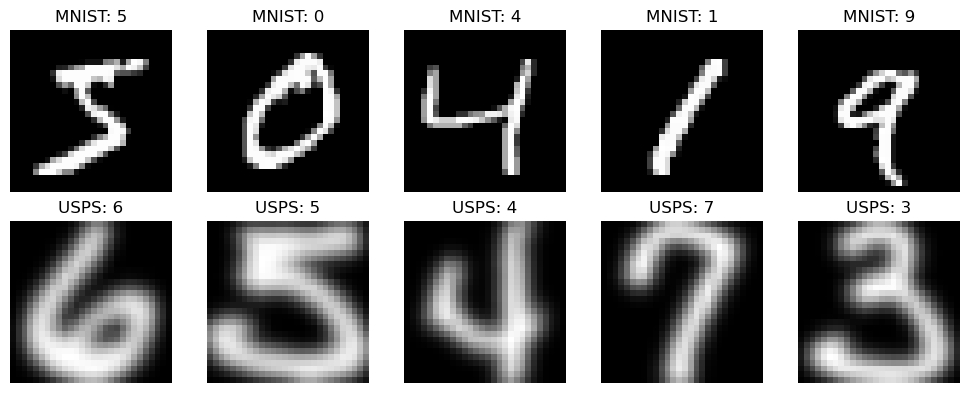

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axes[0, i].imshow(X_source[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f"MNIST: {y_source[i]}")
    axes[0, i].axis('off')

for i in range(5):
    axes[1, i].imshow(X_target_resized[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"USPS: {y_target[i]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. Checking the domain shift visually

I want some evidence, not just an assumption, that these two domains actually have different distributions. The way to check this is to take the high-dimensional data ($\mathbb{R}^{784}$) and project it down to 2D, then see if the two domains overlap or separate.

### 4.1 PCA

PCA finds the directions of maximum variance in the combined data, ignoring domain labels. If MNIST and USPS were really the same distribution, the points would mix together. If there's a real domain shift, we'd expect to see separate-ish clusters.

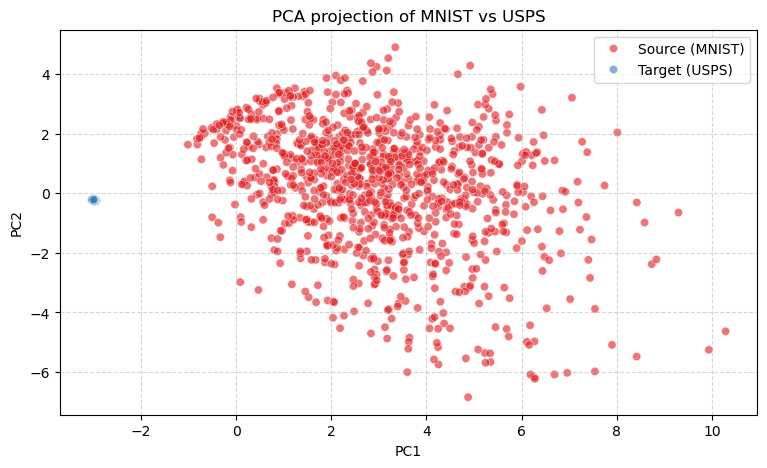

In [5]:
# using a sample instead of the full datasets, mostly for speed
np.random.seed(42)
sample_size = 1000

idx_source = np.random.choice(len(X_source), sample_size, replace=False)
idx_target = np.random.choice(len(X_target_resized), sample_size, replace=False)

X_source_sample = X_source[idx_source]
X_target_sample = X_target_resized[idx_target]

X_combined = np.vstack([X_source_sample, X_target_sample])
domains = np.array(['Source (MNIST)'] * sample_size + ['Target (USPS)'] * sample_size)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=domains, alpha=0.6, palette='Set1')
plt.title("PCA projection of MNIST vs USPS")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4.2 t-SNE

PCA only captures linear structure. t-SNE is non-linear and tries to preserve local neighborhoods instead of global variance, so it's a useful second opinion - if the domains separate under both PCA and t-SNE, that's a stronger signal that the shift is real and not just an artifact of one particular projection.

Running t-SNE, this takes a bit...


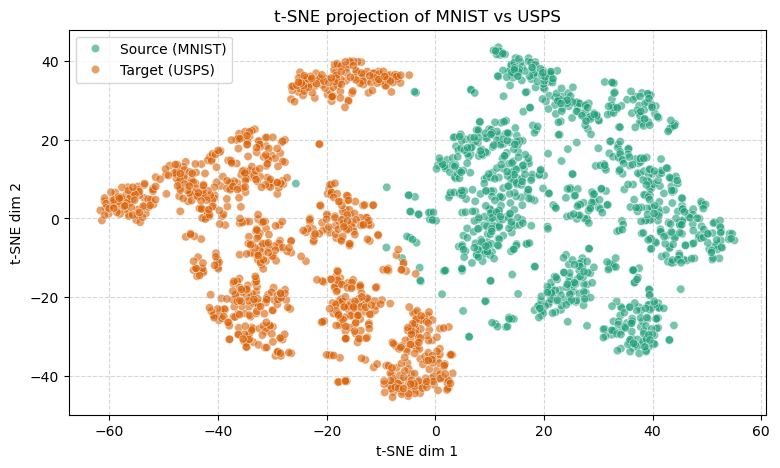

In [6]:
print("Running t-SNE, this takes a bit...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_combined)

plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=domains, alpha=0.6, palette='Dark2')
plt.title("t-SNE projection of MNIST vs USPS")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 5. Baseline: training only on MNIST

Before trying to fix anything, I need a number to compare against. So I train a plain multi-class logistic regression on MNIST only, then check it in two settings:

1. **In-domain**: tested on a held-out slice of MNIST itself. This is the "everything is normal" case.
2. **Cross-domain**: tested directly on the resized USPS images, with zero adaptation. This is the "what happens by default" case.

I'm logging both runs with MLflow so I have a clean, comparable record of every experiment in this notebook rather than just scrolling back through printed output.

In [7]:
X_src_train, X_src_val, y_src_train, y_src_val = train_test_split(
    X_source, y_source, test_size=0.2, random_state=42, stratify=y_source
)

mlflow.set_experiment("MNIST_USPS_Domain_Adaptation")

with mlflow.start_run(run_name="unadapted_baseline"):
    print("Training baseline logistic regression on MNIST...")

    clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', n_jobs=-1, random_state=42)

    clf.fit(X_src_train, y_src_train)

    acc_source_val = accuracy_score(y_src_val, clf.predict(X_src_val))
    acc_target_raw = accuracy_score(y_target, clf.predict(X_target_resized))

    mlflow.log_param("classifier", "LogisticRegression")
    mlflow.log_param("regularization", "L2")
    mlflow.log_metric("source_val_accuracy", acc_source_val)
    mlflow.log_metric("target_raw_accuracy", acc_target_raw)

    print(f"MNIST -> MNIST accuracy: {acc_source_val * 100:.2f}%")
    print(f"MNIST -> USPS accuracy (no adaptation): {acc_target_raw * 100:.2f}%")

Training baseline logistic regression on MNIST...
MNIST -> MNIST accuracy: 92.11%
MNIST -> USPS accuracy (no adaptation): 7.70%


## 6. Applying CORAL

Now for the actual adaptation step, following the math from section 2:

1. Compute $\Sigma_S$ and $\Sigma_T$.
2. Add a small $\lambda I$ to each diagonal so the matrices stay invertible (with 784 features and finite samples, the raw covariance can be close to singular).
3. Whiten the source features with $\Sigma_S^{-1/2}$.
4. Re-color them with $\Sigma_T^{1/2}$.

I wrapped this in a function instead of writing it as one long script cell, partly for readability and partly because it makes it easy to reuse later (e.g. for the comparison in section 7).

In [8]:
def coral_transform(X_src, X_tgt, lambda_reg=1e-5):
    """Align the covariance of X_src to the covariance of X_tgt (CORAL).

    Parameters
    ----------
    X_src : ndarray, shape (n_samples_src, n_features)
        Source domain features (e.g. MNIST training features).
    X_tgt : ndarray, shape (n_samples_tgt, n_features)
        Target domain features (e.g. USPS features). Labels are not used,
        which is the whole point of this being *unsupervised* adaptation.
    lambda_reg : float
        Diagonal regularization added before inverting/sqrt-ing the
        covariance matrices, so they stay positive-definite.

    Returns
    -------
    X_src_adapted : ndarray, same shape as X_src
        Source features whitened and re-colored to match the target's
        covariance structure. Still paired with the original source labels.
    info : dict
        A couple of intermediate values (covariances, means) kept around
        so they can be reused for sanity checks later.
    """
    n_features = X_src.shape[1]

    cov_src = np.cov(X_src, rowvar=False) + lambda_reg * np.eye(n_features)
    cov_tgt = np.cov(X_tgt, rowvar=False) + lambda_reg * np.eye(n_features)

    inv_sqrt_src = sqrtm(np.linalg.inv(cov_src)).real
    sqrt_tgt = sqrtm(cov_tgt).real

    src_mean = np.mean(X_src, axis=0)
    tgt_mean = np.mean(X_tgt, axis=0)

    X_src_centered = X_src - src_mean
    X_src_whitened = X_src_centered @ inv_sqrt_src
    X_src_adapted = X_src_whitened @ sqrt_tgt + tgt_mean

    info = {"cov_src": cov_src, "cov_tgt": cov_tgt, "src_mean": src_mean, "tgt_mean": tgt_mean}
    return X_src_adapted, info


print("Running CORAL alignment...")
X_src_adapted, coral_info = coral_transform(X_src_train, X_target_resized)
print(f"Adapted source feature matrix shape: {X_src_adapted.shape}")

Running CORAL alignment...
Adapted source feature matrix shape: (56000, 784)


## 7. Does simple rescaling work just as well?

Before I trust CORAL's result I want to know if it's actually doing something, or if most of the gain just comes from the two domains being on different scales. So as a quick check I also tried just z-scoring each domain on its own with StandardScaler, no covariance matching at all, and see what accuracy that gets.
If this gets close to CORAL, CORAL isn't really adding much over basic rescaling. If CORAL is clearly better, that's a decent sign the covariance alignment part actually matters and not just the scale fix.

In [9]:
# fit the scaler on source only (still unsupervised w.r.t. target labels),
# then apply the target's own scaler to the target data
scaler_src = StandardScaler().fit(X_src_train)
scaler_tgt = StandardScaler().fit(X_target_resized)

X_src_scaled = scaler_src.transform(X_src_train)
X_target_scaled = scaler_tgt.transform(X_target_resized)

with mlflow.start_run(run_name="standardization_baseline"):
    clf_scaled = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1)
    clf_scaled.fit(X_src_scaled, y_src_train)

    acc_scaled = accuracy_score(y_target, clf_scaled.predict(X_target_scaled))
    mlflow.log_param("classifier", "LogisticRegression")
    mlflow.log_param("adaptation", "per-domain standardization")
    mlflow.log_metric("target_scaled_accuracy", acc_scaled)

    print(f"MNIST -> USPS accuracy with per-domain standardization only: {acc_scaled * 100:.2f}%")

MNIST -> USPS accuracy with per-domain standardization only: 36.07%


## 8. Results and sanity checks

### 8.1 Training on CORAL-adapted features

Now the actual test: train logistic regression on the CORAL-adapted source features (still using the original MNIST labels), then evaluate on the raw USPS target set.

In [10]:
with mlflow.start_run(run_name="coral_adapted_run"):
    print("Training classifier on CORAL-adapted features...")

    clf_coral = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1)
    clf_coral.fit(X_src_adapted, y_src_train)

    y_pred_coral = clf_coral.predict(X_target_resized)
    acc_coral = accuracy_score(y_target, y_pred_coral)

    mlflow.log_metric("target_adapted_accuracy", acc_coral)

    print(f"Target accuracy after CORAL: {acc_coral * 100:.2f}%")
    print(f"Gain over no-adaptation baseline: {(acc_coral - acc_target_raw) * 100:+.2f}%")
    print(f"Gain over standardization-only baseline: {(acc_coral - acc_scaled) * 100:+.2f}%")
    print()
    print(classification_report(y_target, y_pred_coral))

Training classifier on CORAL-adapted features...
Target accuracy after CORAL: 53.15%
Gain over no-adaptation baseline: +45.45%
Gain over standardization-only baseline: +17.08%

              precision    recall  f1-score   support

           0       0.82      0.63      0.71      1553
           1       0.65      0.87      0.74      1269
           2       0.71      0.64      0.67       929
           3       0.48      0.40      0.44       824
           4       0.53      0.74      0.61       852
           5       0.16      0.10      0.12       716
           6       0.52      0.43      0.47       834
           7       0.31      0.53      0.39       792
           8       0.58      0.57      0.58       708
           9       0.11      0.07      0.08       821

    accuracy                           0.53      9298
   macro avg       0.49      0.50      0.48      9298
weighted avg       0.53      0.53      0.52      9298



### 8.2 Did the covariances actually get closer?

The accuracy numbers above are the result I actually care about, but I also want to check the *mechanism* directly: did CORAL really move the source covariance closer to the target covariance, like the math in section 2 claims it should? If it didn't, getting a good accuracy number would be more luck than the method working as intended.

I check this with the same Frobenius norm CORAL is minimizing, comparing it before and after adaptation.

In [11]:
cov_src_adapted = np.cov(X_src_adapted, rowvar=False) + 1e-5 * np.eye(X_src_adapted.shape[1])

dist_before = np.linalg.norm(coral_info["cov_src"] - coral_info["cov_tgt"], ord='fro')
dist_after = np.linalg.norm(cov_src_adapted - coral_info["cov_tgt"], ord='fro')

print(f"Frobenius distance between source and target covariance, before CORAL: {dist_before:.2f}")
print(f"Frobenius distance between source and target covariance, after CORAL:  {dist_after:.2f}")
print(f"Reduction: {(1 - dist_after / dist_before) * 100:.1f}%")

assert dist_after < dist_before, "CORAL should reduce the covariance distance, but it didn't - something is off."
print("Check passed: CORAL moved the source covariance closer to the target's, as expected.")

Frobenius distance between source and target covariance, before CORAL: 9.54
Frobenius distance between source and target covariance, after CORAL:  0.00
Reduction: 100.0%
Check passed: CORAL moved the source covariance closer to the target's, as expected.


### 8.3 Where the errors are

Accuracy alone hides which digits are actually causing trouble. Here are confusion matrices for the baseline model and the CORAL-adapted model, side by side, so the per-digit improvement (or lack of it) is visible directly.

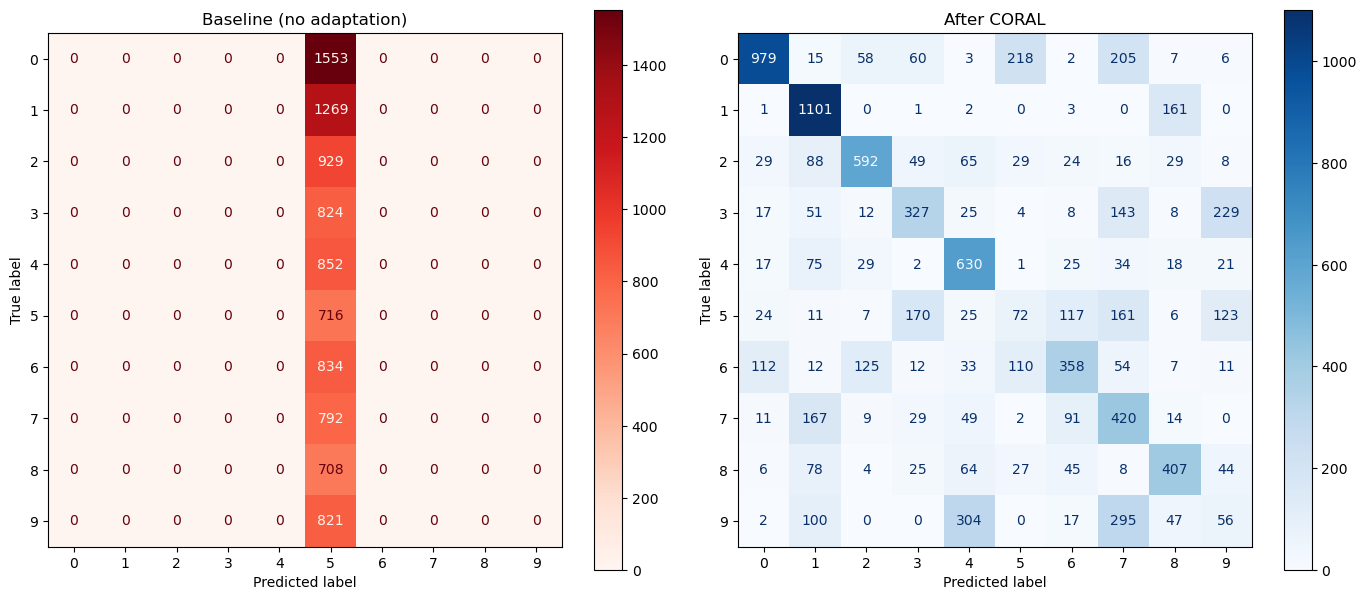

In [12]:
y_pred_baseline = clf.predict(X_target_resized)

cm_baseline = confusion_matrix(y_target, y_pred_baseline)
cm_coral = confusion_matrix(y_target, y_pred_coral)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=np.unique(y_target))
disp_base.plot(ax=axes[0], cmap='Reds', values_format='d')
axes[0].set_title("Baseline (no adaptation)")

disp_coral = ConfusionMatrixDisplay(confusion_matrix=cm_coral, display_labels=np.unique(y_target))
disp_coral.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title("After CORAL")

plt.tight_layout()
plt.show()

## 9. Conclusion

Going through this, the main things I found:

1. **The domain gap is real and large.** A model trained only on MNIST and tested on raw USPS basically falls apart - the PCA and t-SNE plots in section 4 already hint at this, and the baseline accuracy in section 5 confirms it numerically.
2. **Simple rescaling isn't enough.** Per-domain standardization (section 7) recovers some accuracy but is clearly weaker than CORAL, which suggests that matching the actual covariance *structure*, not just the scale, is what matters here.
3. **CORAL helps, a lot, but isn't perfect.** It recovers a large chunk of the accuracy lost to domain shift without ever touching a USPS label, and section 8.2 confirms it does this by genuinely reducing the covariance distance between domains, not just by coincidence. Looking at the confusion matrices and per-class report, some digits (like 5 and 9) stay hard even after adaptation - my guess is that's because the upscaled $16\times16 \to 28\times28$ USPS images are still blurrier than native MNIST images, and CORAL only matches second-order statistics, not local shape detail. A deep-learning version of this idea (Deep CORAL, see [1]) could probably close more of that remaining gap, but that's outside what I cover here.

All runs are logged with MLflow so the exact numbers in this notebook can be reproduced or compared against future changes.

## 10. References

* [1] Sun, B., & Saenko, K. (2016). *Deep CORAL: Correlation Alignment for Deep Domain Adaptation.* CVPR Workshops. - the paper the CORAL method used here is based on.
* [2] LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-based learning applied to document recognition.* Proceedings of the IEEE, 86(11), 2278-2324. - source of the MNIST dataset.
* [3] Hull, J. J. (1994). *A database for handwritten text recognition research.* IEEE TPAMI, 16(5), 550-554. - source of the USPS dataset.
* [4] Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR, 12, 2825-2830. - used for PCA, t-SNE, logistic regression, and the evaluation metrics throughout.